# **Machine Learning for Sepsis Prediction**
---
### Introduction
Sepsis is a life-threatening condition that requires rapid identification and treatment, making early prediction especially valuable in hospital settings. This project explores whether machine learning models can help improve sepsis screening by identifying high-risk patients earlier using clinical data from the 2019 PhysioNet Sepsis Challenge dataset.

Problem statement:
The goal of this notebook it to find key insights on sepsis prevalence and evaluate several classification models for early sepsis prediction. In addition to comparing model performance, this project considers how hospitals could use machine learning to support sepsis screening workflows and improve clinical decision-making.

This notebook addresses the following questions:
1. What are the key insights that can be derived about the prevalence of sepsis from the different classifiers?
2. Which evaluation criteria do you suggest should be applied to evaluate the performance of the different classifiers? Which classifier does best and why?
3. Discuss changes to tools, processes, and jobs that are needed such that a hospital can leverage machine learning to inform its sepsis screening?
4. Should a hospital adopt ML classifiers? Why, why not?

To answer these question the notebook includes the following steps:
1. **Data Loading and Cleaning:**  Load the dataset and handle missing values.
2. **Exploratory Data Analysis (EDA):** Explore data distributions and correlations to understand the features. 
3. **Model Training:** Train various classification models using Decision Tree, Random Forest, AdaBoost, SVM, and XGBoost.
4. **Model Evaluation:** Evaluate models using metrics like accuracy, AUC, classification reports, and confusion matrices.
5. **Model Comparison:** Compare model performance and identify the best model for sepsis prediction.



In [ ]:
!pip install xgboost
!pip install imblearn

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE # Import SMOTE for handling class imbalance
import time



### Data Overview
The dataset contains patient-level observations obtained from three geographically distinct U.S. hospital systems with three diﬀerent electronic medical record systems: Beth Israel Deaconess Medical Center (hospital system A), Emory University Hospital (hospital system B), and a third, unidentified hospital system (hospital system C). The data consists of a combination of hourly vital sign summaries, lab values, and static patient descriptions. In particular, the data contained 40 clinical variables: 8 vital sign variables, 26 laboratory variables, and 6 demographic variables; Table 1 describes these
variables. Altogether, these data included over 2.5 million hourly time windows and 15 million data points.

The columns in the dataset are listed under Table 1 here: https://archive.physionet.org/challenge/2019/#introduction-

In [ ]:
# Load the dataset from the CSV file
df = pd.read_csv('Dataset.csv')

print(df.shape) # Get shape of the dataset (rows, columns)


(1331493, 44)


In [ ]:
df.columns # Display all columns in the dataset

Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
       'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='object')

In [ ]:
df['Patient_ID'].nunique() # Check the number of unique patients


34553

### Data Cleaning


In [ ]:
null_values = df.isnull().mean()*100 # The percentage of null values for each column
null_values = null_values.sort_values(ascending=False) # Sort columns by percentage of null values in descending order
null_values # Display the percentage of null values for each column


,0
Bilirubin_direct,99.818324
Fibrinogen,99.327897
TroponinI,99.185726
Bilirubin_total,98.552602
Alkalinephos,98.416439
AST,98.396912
Lactate,97.208247
EtCO2,97.025745
PTT,96.737046
SaO2,96.300694


In [ ]:
# Get a list of all columns
cols = list(df.columns)

# Remove 'SepsisLabel' from its current position
cols.remove('SepsisLabel')

# Append 'SepsisLabel' to the end for better readability
cols.append('SepsisLabel')

# Reorder the DataFrame columns
df = df[cols]

In [ ]:
df = df.drop(['Unnamed: 0'], axis=1) 


In [ ]:
data = df.sort_values(by=["Patient_ID", "Hour"]) # Sort data by Patient_ID and Hour for proper time-series analysis


In [ ]:
data.head() # Display the first few rows of the sorted data


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID,SepsisLabel
132940,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0.0,NaN,NaN,-0.03,1.0,1.0,0.0
132941,1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,...,NaN,NaN,83.14,0.0,NaN,NaN,-0.03,2.0,1.0,0.0
132942,2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,...,NaN,NaN,83.14,0.0,NaN,NaN,-0.03,3.0,1.0,0.0
132943,3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,...,NaN,NaN,83.14,0.0,NaN,NaN,-0.03,4.0,1.0,0.0
132944,4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,...,NaN,NaN,83.14,0.0,NaN,NaN,-0.03,5.0,1.0,0.0


In [ ]:
# Forward and backward fill missing values within each patient's record
data = data.groupby("Patient_ID").apply(lambda x: x.ffill().bfill())

<ipython-input-11-5d3fd86aa135>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("Patient_ID").apply(lambda x: x.ffill().bfill())


In [ ]:
data.head() # Display the first few rows after filling missing values

Hour     HR  O2Sat   Temp    SBP    MAP  DBP  Resp  EtCO2  \
Patient_ID                                                                     
1.0        132940     0   97.0   95.0  36.11   98.0  75.33  NaN  19.0    NaN   
           132941     1   97.0   95.0  36.11   98.0  75.33  NaN  19.0    NaN   
           132942     2   89.0   99.0  36.11  122.0  86.00  NaN  22.0    NaN   
           132943     3   90.0   95.0  36.11  122.0  86.00  NaN  30.0    NaN   
           132944     4  103.0   88.5  36.11  122.0  91.33  NaN  24.5    NaN   

                   BaseExcess  ...  Fibrinogen  Platelets    Age  Gender  \
Patient_ID                     ...                                         
1.0        132940        24.0  ...         NaN      317.0  83.14     0.0   
           132941        24.0  ...         NaN      317.0  83.14     0.0   
           132942        24.0  ...         NaN      317.0  83.14     0.0   
           132943        24.0  ...         NaN      317.0  83.14     0.0   
           132944        24.0  ...         NaN      317.0  83.14     0.0   

                   Unit1  Unit2  HospAdmTime  ICULOS  Patient_ID  SepsisLabel  
Patient_ID                                                                     
1.0        132940    NaN    NaN        -0.03     1.0         1.0          0.0  
           132941    NaN    NaN        -0.03     2.0         1.0          0.0  
           132942    NaN    NaN        -0.03     3.0         1.0          0.0  
           132943    NaN    NaN        -0.03     4.0         1.0          0.0  
           132944    NaN    NaN        -0.03     5.0         1.0          0.0  

[5 rows x 43 columns]

In [ ]:
# Fill any remaining missing values with the column mean
data = data.apply(lambda x: x.fillna(x.median()))

In [ ]:
data.head() # Display the first few rows after filling with mean


Hour     HR  O2Sat   Temp    SBP    MAP   DBP  Resp  EtCO2  \
Patient_ID                                                                      
1.0        132940     0   97.0   95.0  36.11   98.0  75.33  62.0  19.0   33.5   
           132941     1   97.0   95.0  36.11   98.0  75.33  62.0  19.0   33.5   
           132942     2   89.0   99.0  36.11  122.0  86.00  62.0  22.0   33.5   
           132943     3   90.0   95.0  36.11  122.0  86.00  62.0  30.0   33.5   
           132944     4  103.0   88.5  36.11  122.0  91.33  62.0  24.5   33.5   

                   BaseExcess  ...  Fibrinogen  Platelets    Age  Gender  \
Patient_ID                     ...                                         
1.0        132940        24.0  ...       277.0      317.0  83.14     0.0   
           132941        24.0  ...       277.0      317.0  83.14     0.0   
           132942        24.0  ...       277.0      317.0  83.14     0.0   
           132943        24.0  ...       277.0      317.0  83.14     0.0   
           132944        24.0  ...       277.0      317.0  83.14     0.0   

                   Unit1  Unit2  HospAdmTime  ICULOS  Patient_ID  SepsisLabel  
Patient_ID                                                                     
1.0        132940    0.0    1.0        -0.03     1.0         1.0          0.0  
           132941    0.0    1.0        -0.03     2.0         1.0          0.0  
           132942    0.0    1.0        -0.03     3.0         1.0          0.0  
           132943    0.0    1.0        -0.03     4.0         1.0          0.0  
           132944    0.0    1.0        -0.03     5.0         1.0          0.0  

[5 rows x 43 columns]

In [ ]:
# Reset the index to sequential numbers, basically undo group by previously done
data = data.reset_index(drop=True)

In [ ]:
# Recalculate and display null values to confirm if any remain
null_values = data.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_values

,0
Hour,0.0
WBC,0.0
Magnesium,0.0
Phosphate,0.0
Potassium,0.0
Bilirubin_total,0.0
TroponinI,0.0
Hct,0.0
Hgb,0.0
PTT,0.0


In [ ]:
# LabelEncoder to convert categorical values into numerical values
label_encoder = LabelEncoder()
data['SepsisLabel'] = label_encoder.fit_transform(data['SepsisLabel'])

In [ ]:
data['SepsisLabel'].dtype

dtype('int64')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1331492 entries, 0 to 1331491
Data columns (total 43 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Hour              1331492 non-null  int64  
 1   HR                1331492 non-null  float64
 2   O2Sat             1331492 non-null  float64
 3   Temp              1331492 non-null  float64
 4   SBP               1331492 non-null  float64
 5   MAP               1331492 non-null  float64
 6   DBP               1331492 non-null  float64
 7   Resp              1331492 non-null  float64
 8   EtCO2             1331492 non-null  float64
 9   BaseExcess        1331492 non-null  float64
 10  HCO3              1331492 non-null  float64
 11  FiO2              1331492 non-null  float64
 12  pH                1331492 non-null  float64
 13  PaCO2             1331492 non-null  float64
 14  SaO2              1331492 non-null  float64
 15  AST               1331492 non-null  float64
 16  

In [ ]:
# # Standard scaling on non-categorical data
# # Commented out for now, consider using if needed

# exclude_columns = ['Patient_ID', 'SepsisLabel']
# columns_to_scale = [col for col in data.columns if col not in exclude_columns]

# scaler = StandardScaler()
# data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])
# data.head()

### EDA


In [ ]:


# Count the occurrences of each unique value in the 'SepsisLabel' column
sepsis_counts = data['SepsisLabel'].value_counts()
sepsis_counts

,count
SepsisLabel,
0,1306681
1,24811


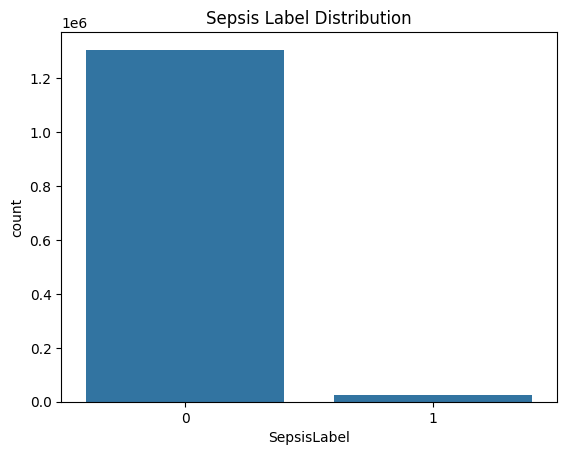

In [ ]:
# Create a countplot of the SepsisLabel column
sns.countplot(x="SepsisLabel", data=data) 
plt.title('Sepsis Label Distribution') 
plt.show() 

#### There is a significant class imbalance.
By oversampling the minority class (patients with sepsis) using SMOTE, it will prevent the model from being biased towards the majority class and improves its ability to predict sepsis accurately.


In [ ]:
X = data.drop('SepsisLabel', axis=1)
y = data['SepsisLabel']

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create a new DataFrame from the resampled data
resampled_data = pd.DataFrame(X_resampled, columns=X.columns)
resampled_data['SepsisLabel'] = y_resampled

# Concatenate the original and resampled DataFrames
data = resampled_data

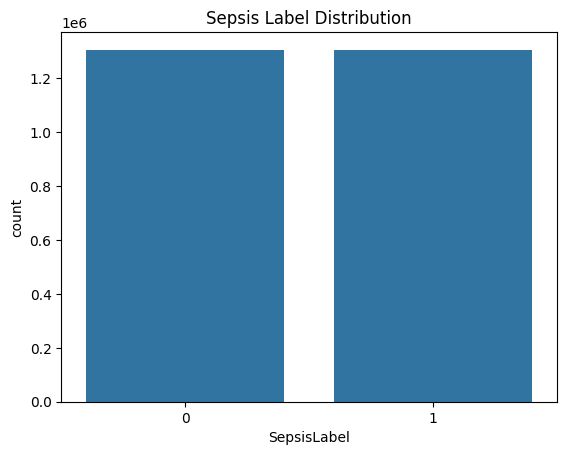

In [ ]:
# Create a countplot of the SepsisLabel column
sns.countplot(x="SepsisLabel", data=data) 
plt.title('Sepsis Label Distribution') 
plt.show() 

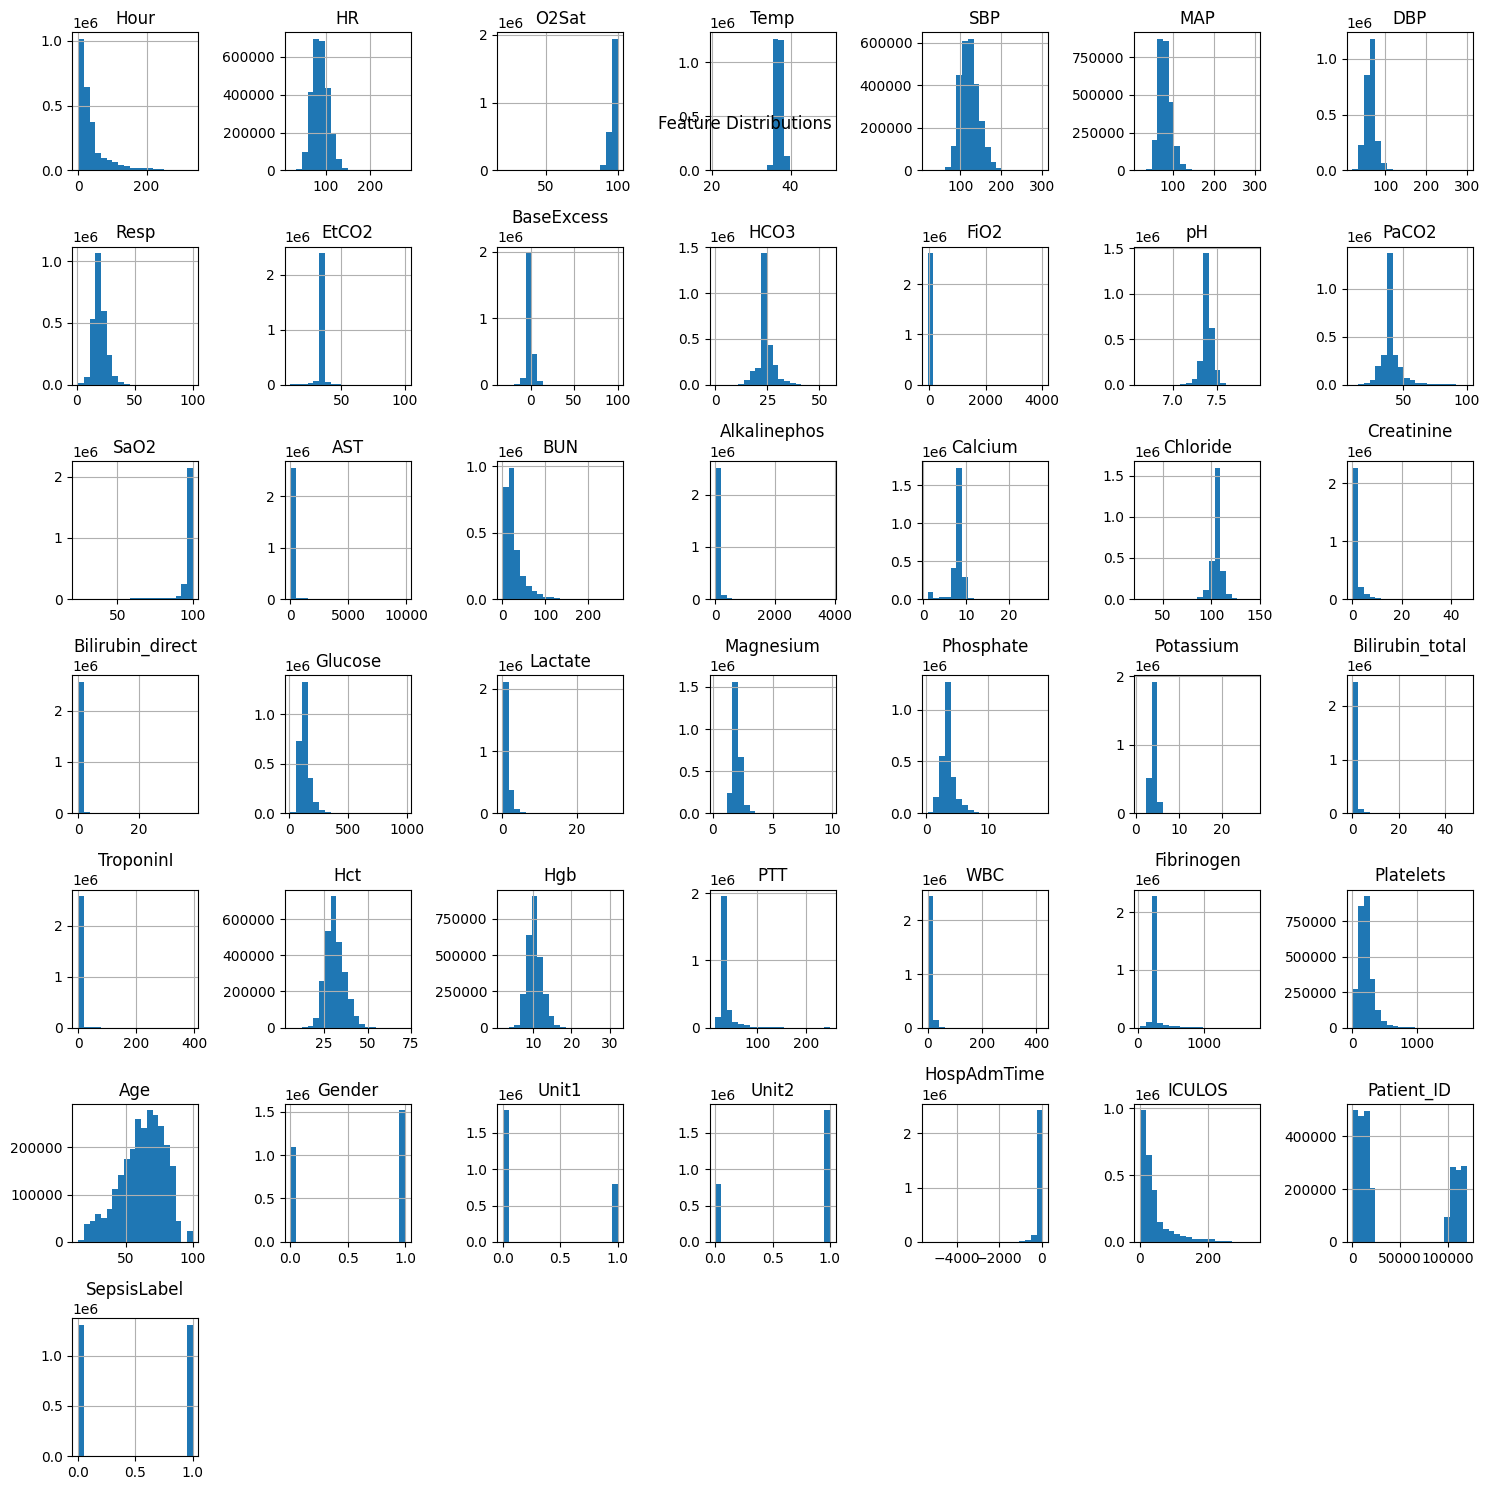

In [ ]:

numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Create histograms for numerical features
data[numerical_columns].hist(bins=20, figsize=(15, 15))
plt.tight_layout() # Adjust the layout for better readability
plt.suptitle("Feature Distributions", y=0.92)
plt.show() # Display the plot

<Axes: >

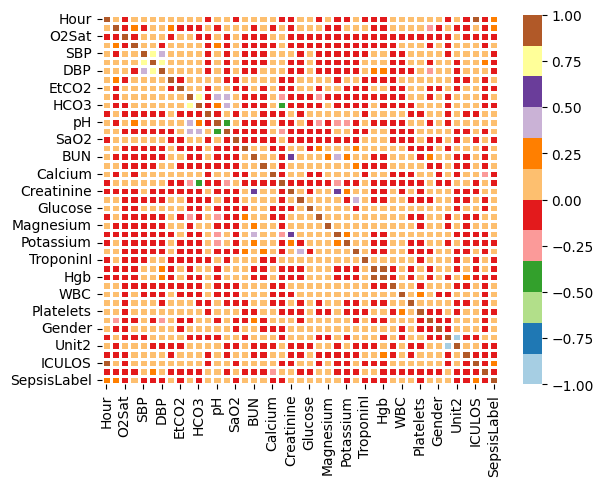

In [ ]:
corr = data.corr()  # Calculate the correlation matrix
sns.heatmap(corr, cmap="Paired", linewidths = 1, cbar=True)

There's a strong positive correlation between systolic BP and Diastolic BP. 

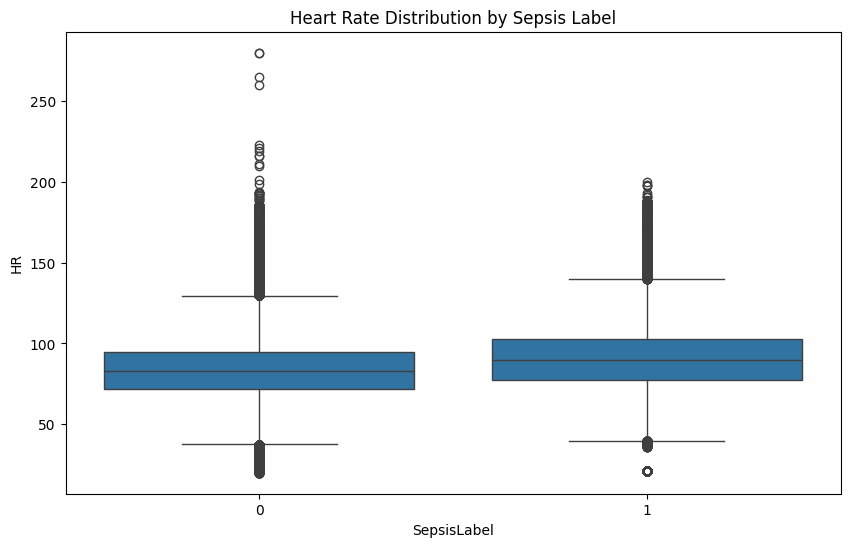

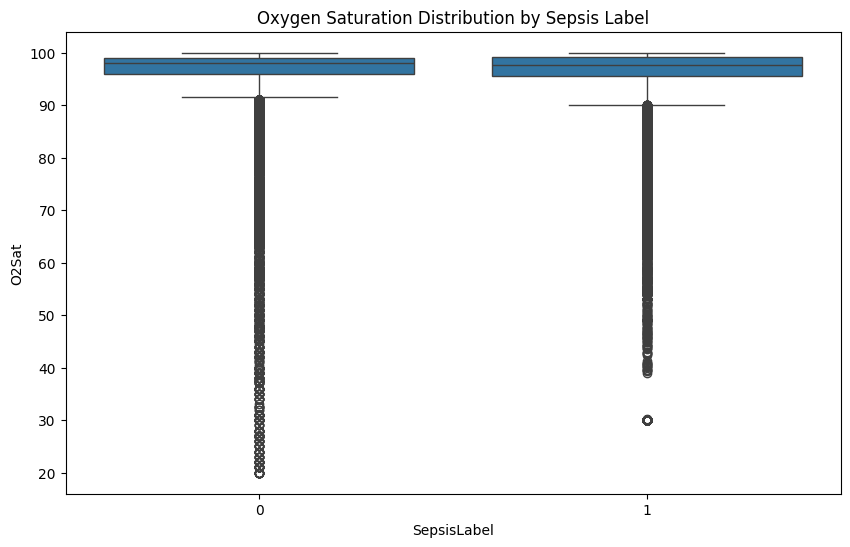

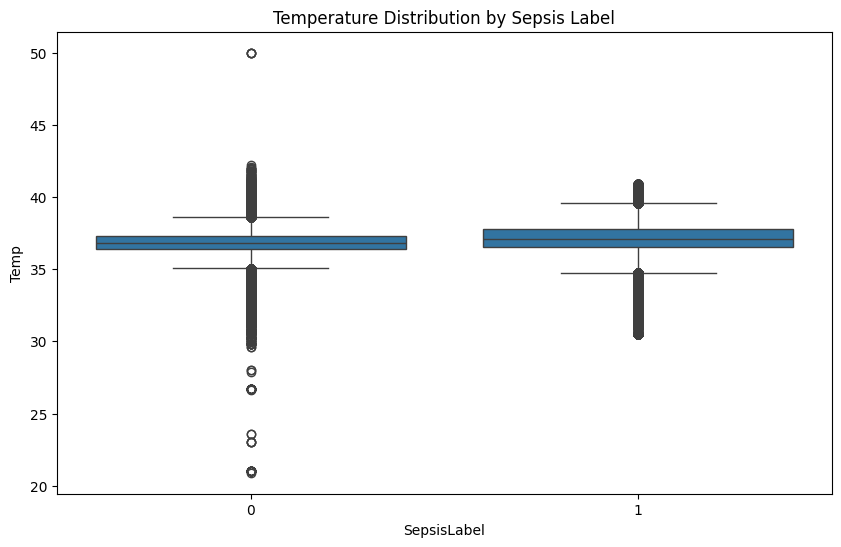

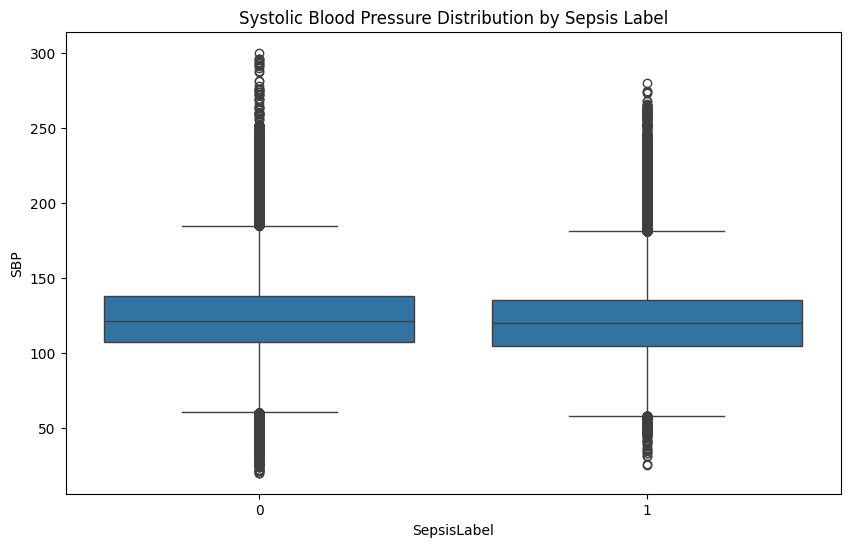

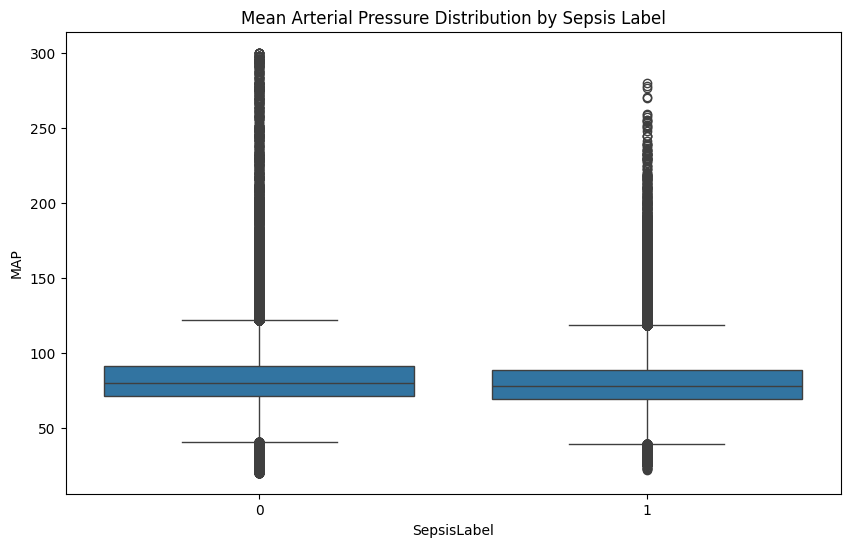

In [ ]:
# Analyze specific columns with boxplots to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='SepsisLabel', y='HR', data=data)
plt.title('Heart Rate Distribution by Sepsis Label')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='SepsisLabel', y='O2Sat', data=data)
plt.title('Oxygen Saturation Distribution by Sepsis Label')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='SepsisLabel', y='Temp', data=data)
plt.title('Temperature Distribution by Sepsis Label')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='SepsisLabel',y='SBP',data=data)
plt.title('Systolic Blood Pressure Distribution by Sepsis Label')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='SepsisLabel',y='MAP',data=data)
plt.title('Mean Arterial Pressure Distribution by Sepsis Label')
plt.show()



In [ ]:
# Entire Table Display

pd.set_option("display.max_rows", None, "display.max_columns", None)

In [ ]:
# Key features grouped by SepsisLabel

print(data.groupby('SepsisLabel')[['HR', 'O2Sat', 'Temp', 'SBP', 'MAP']].describe())

                    HR                                                    \
                 count       mean        std   min        25%        50%   
SepsisLabel                                                                
0            1306681.0  84.365776  17.279340  20.0  72.000000  83.000000   
1            1306681.0  90.536285  18.367811  21.0  77.484034  89.876251   

                                    O2Sat                             \
                    75%    max      count       mean       std   min   
SepsisLabel                                                            
0             95.000000  280.0  1306681.0  97.165583  3.121792  20.0   
1            102.571905  200.0  1306681.0  96.991321  3.234296  30.0   

                                                          Temp             \
                   25%        50%        75%    max      count       mean   
SepsisLabel                                                                 
0            96.000000  98.

The mean values for sepsis patients:
HR - 90 beats per minute
Pulse oximetry 96%
Temperature - 37.1 Deg C
Systolic BP - 121 (pretty avg)
MAP - 79.8 mm Hg

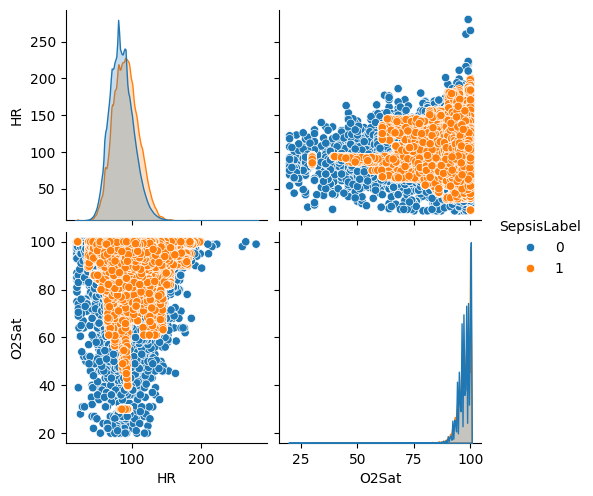

In [ ]:
# Relationship between features using pairplots for a subset of features
subset_features = ['HR', 'O2Sat', 'SepsisLabel']
sns.pairplot(data[subset_features], hue='SepsisLabel')
plt.show()

### Feature Selection

In [ ]:
data = data.drop(['Patient_ID'], axis=1) # Drop the 'Patient_ID' column as it is not a feature


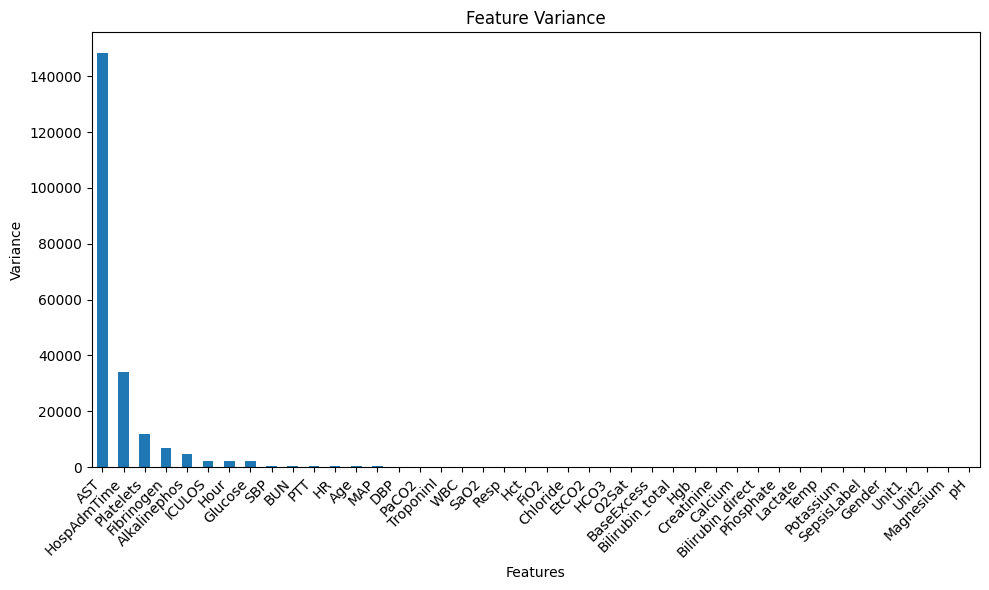

In [ ]:

# Calculate the variance of each numerical feature
variance = data.select_dtypes(include=['float64', 'int64']).var()

# Sort features by variance in descending order
variance_sorted = variance.sort_values(ascending=False)

# Bar plot to visualize feature variance
plt.figure(figsize=(10, 6))
variance_sorted.plot(kind='bar')
plt.title('Feature Variance')
plt.xlabel('Features')
plt.ylabel('Variance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature Selection

In [ ]:
correlation_with_target = data.corr()['SepsisLabel'].abs().sort_values(ascending=False)
print(correlation_with_target)

SepsisLabel         1.000000
ICULOS              0.304825
Hour                0.300343
HR                  0.170486
Temp                0.155174
Resp                0.149551
BUN                 0.139425
Hgb                 0.104963
Hct                 0.100629
WBC                 0.093240
Bilirubin_total     0.075327
MAP                 0.072724
HospAdmTime         0.062596
Fibrinogen          0.062046
Calcium             0.060529
Creatinine          0.060111
DBP                 0.054755
Alkalinephos        0.048184
Lactate             0.048106
Bilirubin_direct    0.047062
SBP                 0.046195
Magnesium           0.046169
PTT                 0.046163
Glucose             0.040178
Gender              0.035229
BaseExcess          0.031943
Unit1               0.031037
Unit2               0.031037
O2Sat               0.027402
AST                 0.026433
EtCO2               0.025491
Phosphate           0.022114
SaO2                0.021071
pH                  0.017684
Potassium     

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

X = data.drop('SepsisLabel', axis=1) # Define features (X) by dropping the target variable
y = data['SepsisLabel'] # Define the target variable (y)

# Select top k features based on ANOVA F-value
selector = SelectKBest(f_classif, k=10)  # Select top 5 features
X_new = selector.fit_transform(X, y)

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['Hour', 'HR', 'Temp', 'Resp', 'BUN', 'Bilirubin_total', 'Hct', 'Hgb',
       'WBC', 'ICULOS'],
      dtype='object')


### Model Training


In [ ]:

X = data.drop('SepsisLabel', axis=1) # Define features (X) by dropping the target variable
y = data['SepsisLabel'] # Define the target variable (y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data into training and testing sets


In [ ]:
# Models and Parameter Grids

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    #"XGBoost": XGBClassifier(random_state=42),
    #"SVM": SVC(probability=False, random_state=42)
}

param_grids = {
    "Decision Tree": {"max_depth": [3, 5, 10]},
    "Random Forest": {"n_estimators": [50, 100], "n_jobs": [3, 4], "max_depth": [5, 10]},
    "AdaBoost": {"n_estimators": [50, 100], "learning_rate": [0.5, 1.0]},
    #"XGBoost": {"n_estimators": [50, 100], "max_depth": [3, 6]},
    #"SVM": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
}

Training Decision Tree with GridSearchCV...
Decision Tree Accuracy: 0.7832
Decision Tree Balanced Accuracy: 0.7832
Decision Tree AUC: 0.8672
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.77    261020
           1       0.76      0.82      0.79    261653

    accuracy                           0.78    522673
   macro avg       0.78      0.78      0.78    522673
weighted avg       0.78      0.78      0.78    522673

Decision Tree Confusion Matrix:
[[194750  66270]
 [ 47048 214605]]
Decision Tree Refit Time: 169.48 seconds
Decision Tree Best Parameters: {'max_depth': 10}
----------------------------------------
Training Random Forest with GridSearchCV...


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest Accuracy: 0.8650
Random Forest Balanced Accuracy: 0.8651
Random Forest AUC: 0.9301
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87    261020
           1       0.90      0.82      0.86    261653

    accuracy                           0.87    522673
   macro avg       0.87      0.87      0.86    522673
weighted avg       0.87      0.87      0.86    522673

Random Forest Confusion Matrix:
[[236866  24154]
 [ 46398 215255]]
Random Forest Refit Time: 3266.09 seconds
Random Forest Best Parameters: {'max_depth': 10, 'n_estimators': 100, 'n_jobs': 3}
----------------------------------------
Training AdaBoost with GridSearchCV...


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


AdaBoost Accuracy: 0.7886
AdaBoost Balanced Accuracy: 0.7887
AdaBoost AUC: 0.8726
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80    261020
           1       0.82      0.74      0.78    261653

    accuracy                           0.79    522673
   macro avg       0.79      0.79      0.79    522673
weighted avg       0.79      0.79      0.79    522673

AdaBoost Confusion Matrix:
[[218943  42077]
 [ 68399 193254]]
AdaBoost Refit Time: 3229.19 seconds
AdaBoost Best Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
----------------------------------------


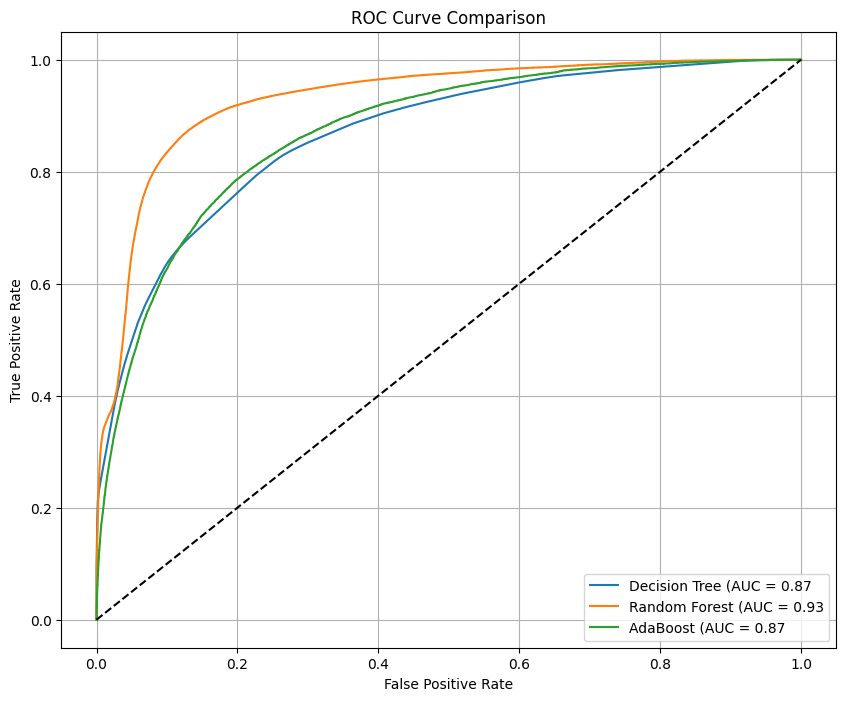

In [ ]:

# Train, Evaluate, and Compare Models
results = {}
roc_data = {}

plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    print(f"Training {model_name} with GridSearchCV...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    time_taken = time.time() - start_time

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Performance Metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} Balanced Accuracy: {balanced_acc:.4f}")
    print(f"{model_name} AUC: {auc_score:.4f}")
    print(f"{model_name} Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"{model_name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"{model_name} Refit Time: {time_taken:.2f} seconds")
    print(f"{model_name} Best Parameters: {grid_search.best_params_}")
    print('-'*40)

    results[model_name] = {
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "AUC": auc_score,
        "TPR": tpr,
        "FPR": fpr,
        "Refit Time": time_taken,
        "Best Params": grid_search.best_params_
    }

    roc_data[model_name] = (fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f}')

# ROC Plot
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Compare performance
best_model = max(results, key=lambda x: results[x]["Accuracy"])  # Find the model with the highest accuracy
print("\nPerformance Comparison:")
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics['Accuracy']:.4f}")  # Print accuracy for each model
print(f"\nBest Model: {best_model} with Accuracy: {results[best_model]['Accuracy']:.4f}")


Performance Comparison:
Decision Tree: 0.7832
Random Forest: 0.8650
AdaBoost: 0.7886

Best Model: Random Forest with Accuracy: 0.8650
